In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Visualization of Olympics 2024

In [5]:
athletes_data = pd.read_csv('https://raw.githubusercontent.com/najiha2002/dataset/refs/heads/main/athletes.csv')

In [3]:
athletes_data.head()

,code,current,name,name_short,name_tv,gender,function,country_code,country,country_long,...,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Father, Gevorg Aleksanyan","Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN
1,1532873,True,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,NaN,NaN,NaN,NaN,"""To become a good athlete, you first have to b...","Uncle, Roman Amoyan (wrestling), 2008 Olympic ...",NaN,NaN
2,1532874,True,GALSTYAN Slavik,GALSTYAN S,Slavik GALSTYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,Personal: Martin Alekhanyan (ARM).<br>National...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1532944,True,HARUTYUNYAN Arsen,HARUTYUNYAN A,Arsen HARUTYUNYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Diana (married October 2022). Daughter, ...",Armenian,National: Habetnak Kurghinyan,While doing karate he noticed wrestlers traini...,"Wrestler Armen Nazaryan (ARM, BUL), two-time O...",NaN,"“Nothing is impossible, set goals in front of ...",NaN,NaN,NaN
4,1532945,True,TEVANYAN Vazgen,TEVANYAN V,Vazgen TEVANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Sona (married November 2023)","Armenian, Russian",National: Habetnak Kurghinyan (ARM),“My family did not like wrestling very much. A...,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
athletes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                11113 non-null  int64  
 1   current             11113 non-null  bool   
 2   name                11113 non-null  object 
 3   name_short          11110 non-null  object 
 4   name_tv             11110 non-null  object 
 5   gender              11113 non-null  object 
 6   function            11113 non-null  object 
 7   country_code        11113 non-null  object 
 8   country             11113 non-null  object 
 9   country_long        11113 non-null  object 
 10  nationality         11110 non-null  object 
 11  nationality_long    11110 non-null  object 
 12  nationality_code    11110 non-null  object 
 13  height              11110 non-null  float64
 14  weight              11108 non-null  float64
 15  disciplines         11113 non-null  object 
 16  even

##Athlete Informations

### No of male and female athlete

In [8]:
print(athletes_data['gender'].value_counts())

gender
Male      5658
Female    5455
Name: count, dtype: int64


<Axes: xlabel='gender', ylabel='count'>

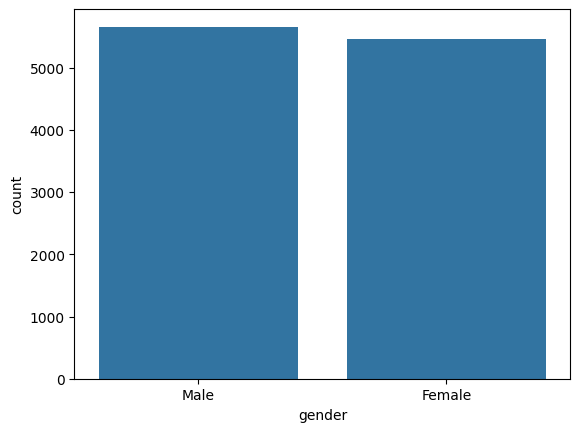

In [9]:
# normal bar chart
sns.countplot(athletes_data, x=athletes_data['gender'])

### Top 10 countries with highest no of athletes

In [19]:
top = athletes_data['country'].value_counts().head(10).index
# value_counts() will automatically sort descendingly
# .index to get countries only

print(top)

Index(['United States', 'France', 'Australia', 'Germany', 'Japan', 'Spain',
       'China', 'Italy', 'Great Britain', 'Canada'],
      dtype='object', name='country')


In [22]:
# filter the original dataset based on above countries only using the index list
top_10 = athletes_data[athletes_data['country'].isin(top)]

print(top_10.head())

        code  current             name  name_short          name_tv  gender  \
464  1541265     True    BARBELIN Lisa  BARBELIN L    Lisa BARBELIN  Female   
465  1541266     True   CORDEAU Amelie   CORDEAU A   Amelie CORDEAU  Female   
466  1541268     True   LOPEZ Caroline     LOPEZ C   Caroline LOPEZ  Female   
467  1541270     True   ADDIS Baptiste     ADDIS B   Baptiste ADDIS    Male   
468  1541272     True  CHIRAULT Thomas  CHIRAULT T  Thomas CHIRAULT    Male   

    function country_code country country_long  ...  \
464  Athlete          FRA  France       France  ...   
465  Athlete          FRA  France       France  ...   
466  Athlete          FRA  France       France  ...   
467  Athlete          FRA  France       France  ...   
468  Athlete          FRA  France       France  ...   

                                                family    lang  \
464  Partner, Thomas Chirault. Father, Olivier. Mot...  French   
465                 Father, Richard. Mother, Geraldine  French

<Axes: xlabel='country', ylabel='count'>

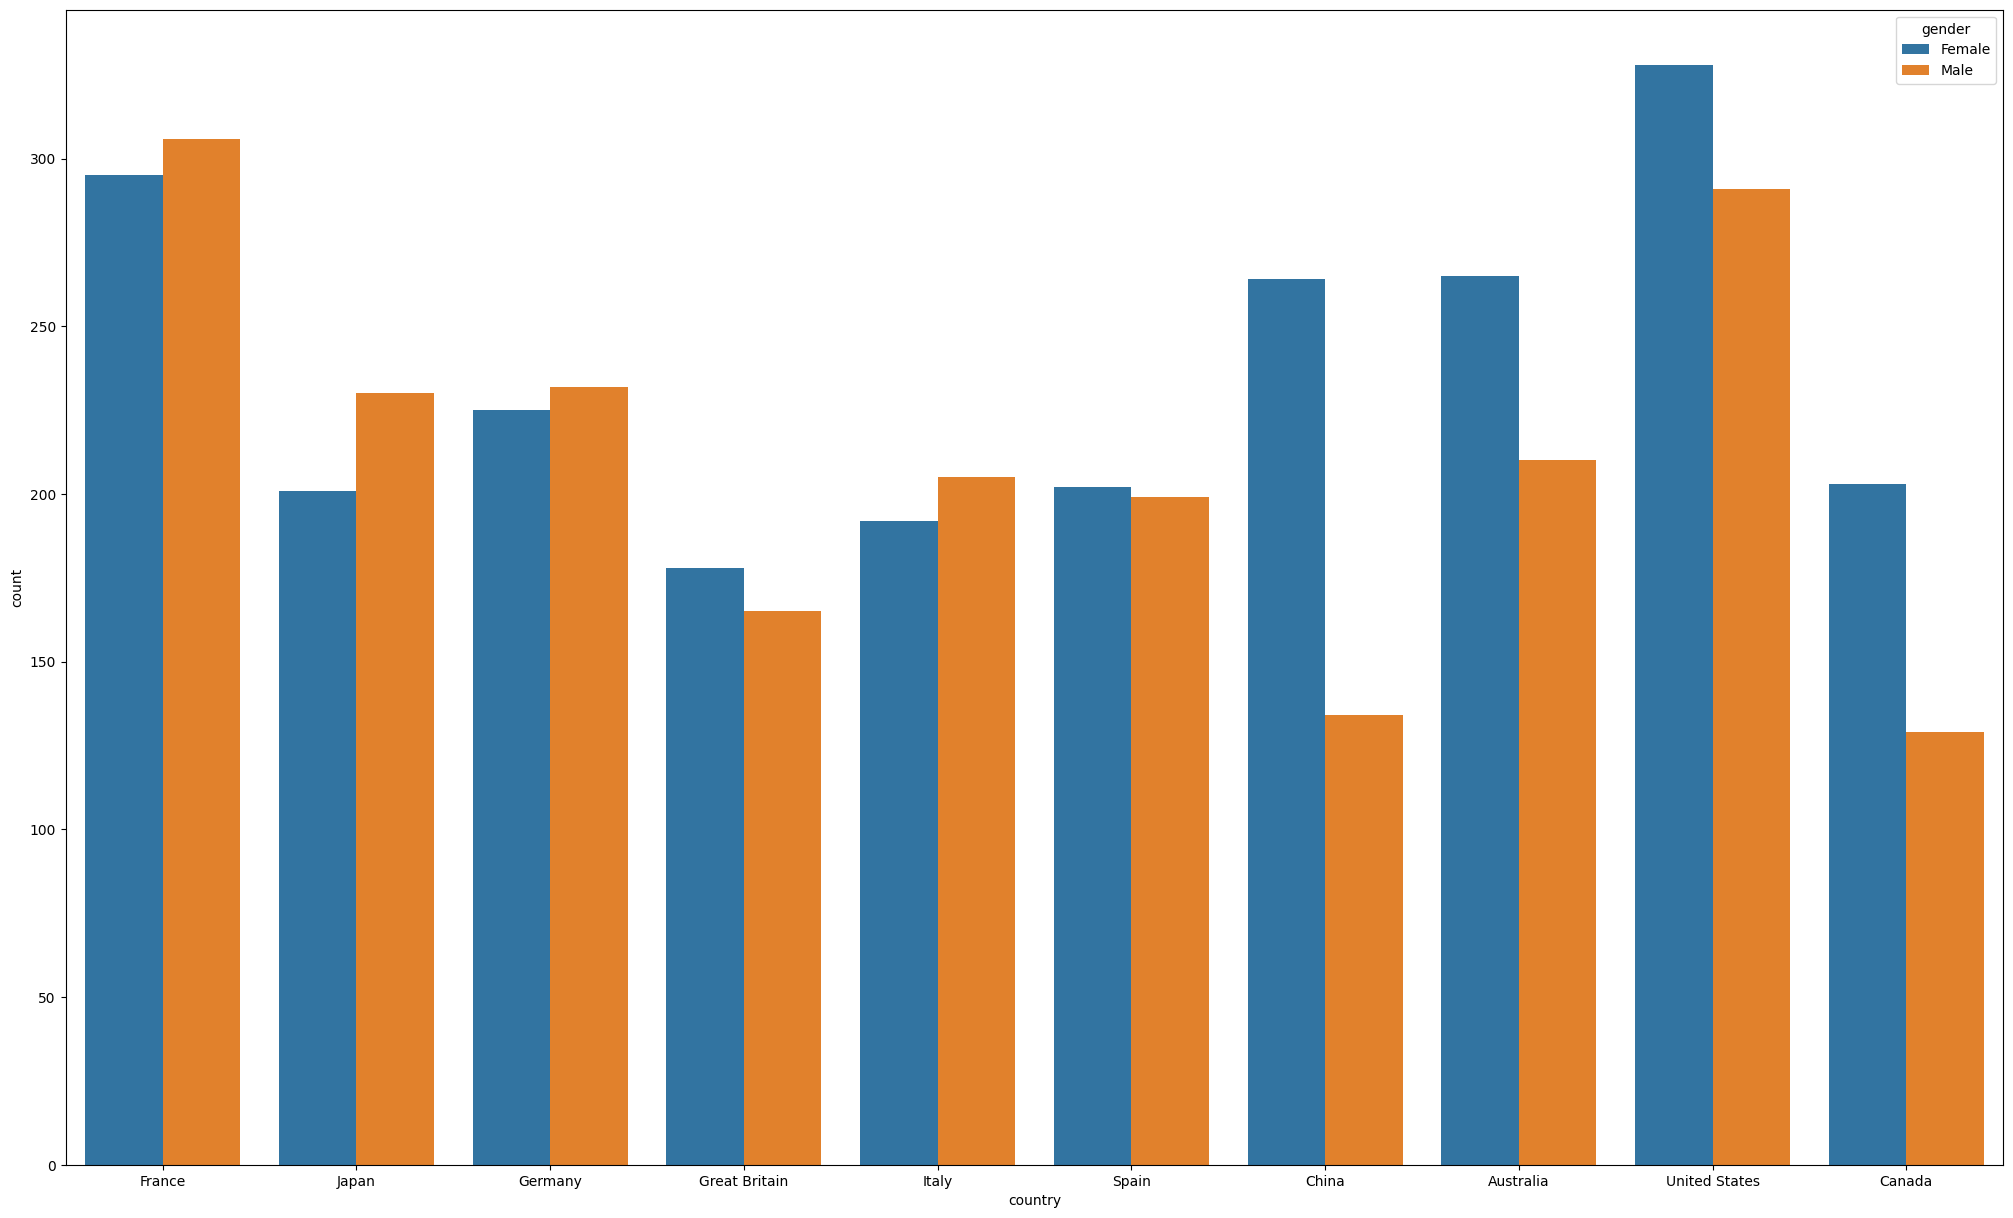

In [25]:
plt.figure(figsize=(25,15))
sns.countplot(top_10, x=top_10['country'], hue='gender')

###Top 5 countries with highest no of male participant

In [30]:
male = athletes_data[athletes_data['gender'] == 'Male']
top_male = male['country'].value_counts().head(5).index
top_male_countries = male[male['country'].isin(top_male)]

In [ ]:
# the point is to get the rows of data (filtered data) that satisfy the question/instruction before we can plot it out

In [34]:
sorted_countries = top_male[::-1] # sort ascendingly

print(sorted_countries)

Index(['Australia', 'Japan', 'Germany', 'United States', 'France'], dtype='object', name='country')


<Axes: xlabel='country', ylabel='count'>

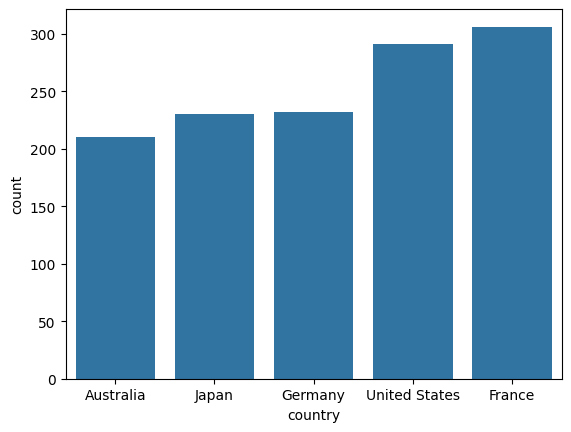

In [35]:
sns.countplot(top_male_countries, x=top_male_countries['country'], order=sorted_countries)

###Top 5 countries with highest no of female participant

In [41]:
# female data only
female = athletes_data[athletes_data['gender']=='Female']
# country index list
top_female = female['country'].value_counts().head().index
# filter data based on country index list (if the country column is in country index list)
top_female_countries = female[female['country'].isin(top_female)]

<Axes: xlabel='country', ylabel='count'>

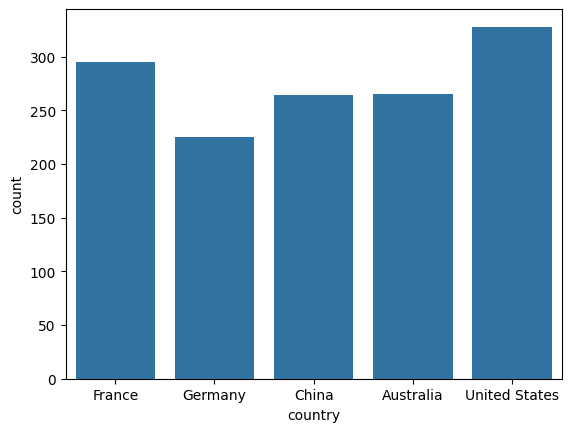

In [42]:
sns.countplot(top_female_countries, x='country')

### Top 8 games with highest no of participant

In [44]:
athletes_data['disciplines'].unique()

array(["['Wrestling']", "['Athletics']", "['Judo']", "['Triathlon']",
       "['Swimming']", "['Artistic Swimming']", "['Weightlifting']",
       "['Canoe Slalom']", "['Boxing']", "['Sailing']", "['Rowing']",
       "['Artistic Gymnastics']", "['Diving']", "['Equestrian']",
       "['Rhythmic Gymnastics']", "['Modern Pentathlon']",
       "['Taekwondo']", "['Surfing']", "['Cycling Road']", "['Archery']",
       "['Shooting']", "['Canoe Sprint']", "['Football']",
       "['Marathon Swimming']", "['Sport Climbing']", "['Table Tennis']",
       "['Golf']", "['Badminton']", "['Hockey']",
       "['Cycling BMX Racing']", "['Fencing']", "['Rugby Sevens']",
       "['Marathon Swimming', 'Swimming']", "['Cycling Track']",
       "['Handball']", "['Skateboarding']", "['Cycling Mountain Bike']",
       "['Tennis']", "['Breaking']", "['Trampoline Gymnastics']",
       "['Cycling BMX Freestyle']", "['Beach Volleyball']",
       "['Basketball']", "['Water Polo']",
       "['Cycling Road', 'Cycling 

In [48]:
# games index list
top_games = athletes_data['disciplines'].value_counts().head(8).index
# filter data based on games index list
top_8_games = athletes_data[athletes_data['disciplines'].isin(top_games)]

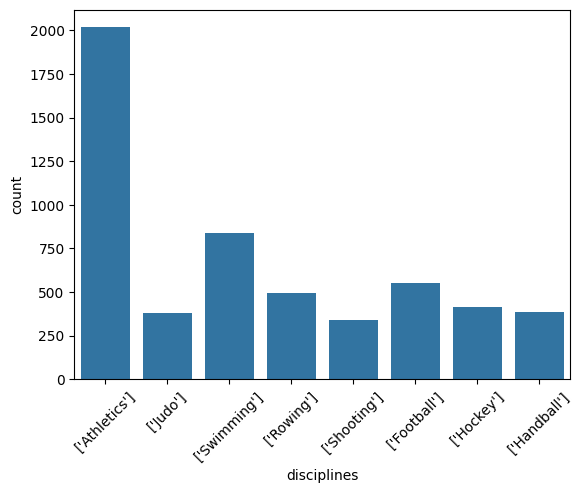

In [52]:
sns.countplot(top_8_games, x='disciplines')
plt.xticks(rotation=45, fontsize=10)
plt.show()

### Top 8 games with lowest no of participant

In [55]:
# games index list - changing head to tail
bot_games = athletes_data['disciplines'].value_counts().tail(8).index
# filter data based on games index list
bot_8_games = athletes_data[athletes_data['disciplines'].isin(bot_games)]

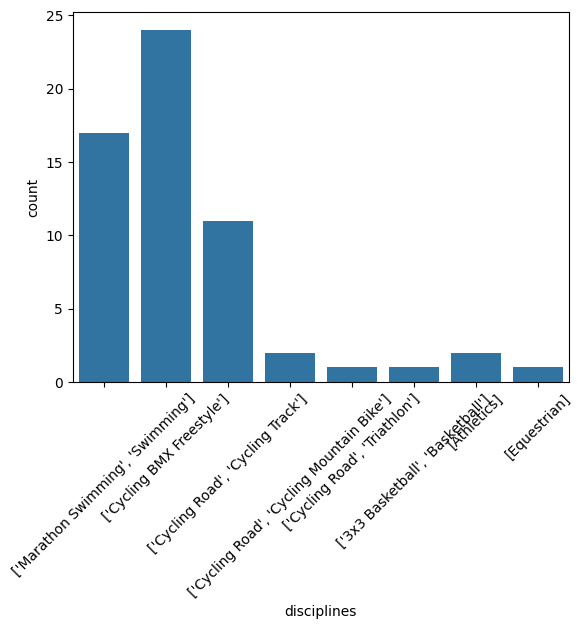

In [58]:
sns.countplot(bot_8_games, x='disciplines')
plt.xticks(rotation=45, fontsize=10)
plt.show()

### Top 10 countries with lowest no of athletes

### Athlete age analysis

In [61]:
from datetime import datetime

# calculate age to get birth date
athletes_data['birth_date'] = pd.to_datetime(athletes_data['birth_date'])
athletes_data['age'] = athletes_data['birth_date'].apply(lambda birth_date: (datetime.now() - birth_date).days // 365)
# double slash means i want to get the integer or the age without decimal after dividing with 365

<Axes: xlabel='age', ylabel='Count'>

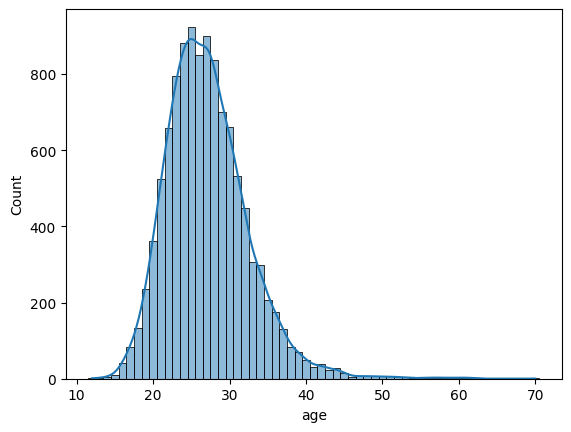

In [66]:
bins = [0, 18, 25, 35, 45, 55, 65, 75, 85, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76-85', '86-100']
sns.histplot(data=athletes_data, x='age', discrete=True, kde=True)